k-NEAREST NEIGHBORS CLASSIFIER IMPLEMENTATION
Customer Purchase Data Classification

1. LOADING DATA FROM EXCEL...
----------------------------------------
Excel file loaded successfully!
Columns found: ['Customer', 'Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)', 'Payment (Rs)', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Candy', 'Mango', 'Milk']
Shape: (10, 22)

First 5 rows:
  Customer  Candies (#)  Mangoes (Kg)  Milk Packets (#)  Payment (Rs)  \
0      C_1           20             6                 2           386   
1      C_2           16             3                 6           289   
2      C_3           27             6                 2           393   
3      C_4           19             1                 2           110   
4      C_5           24             4                 2           280   

   Unnamed: 5  U

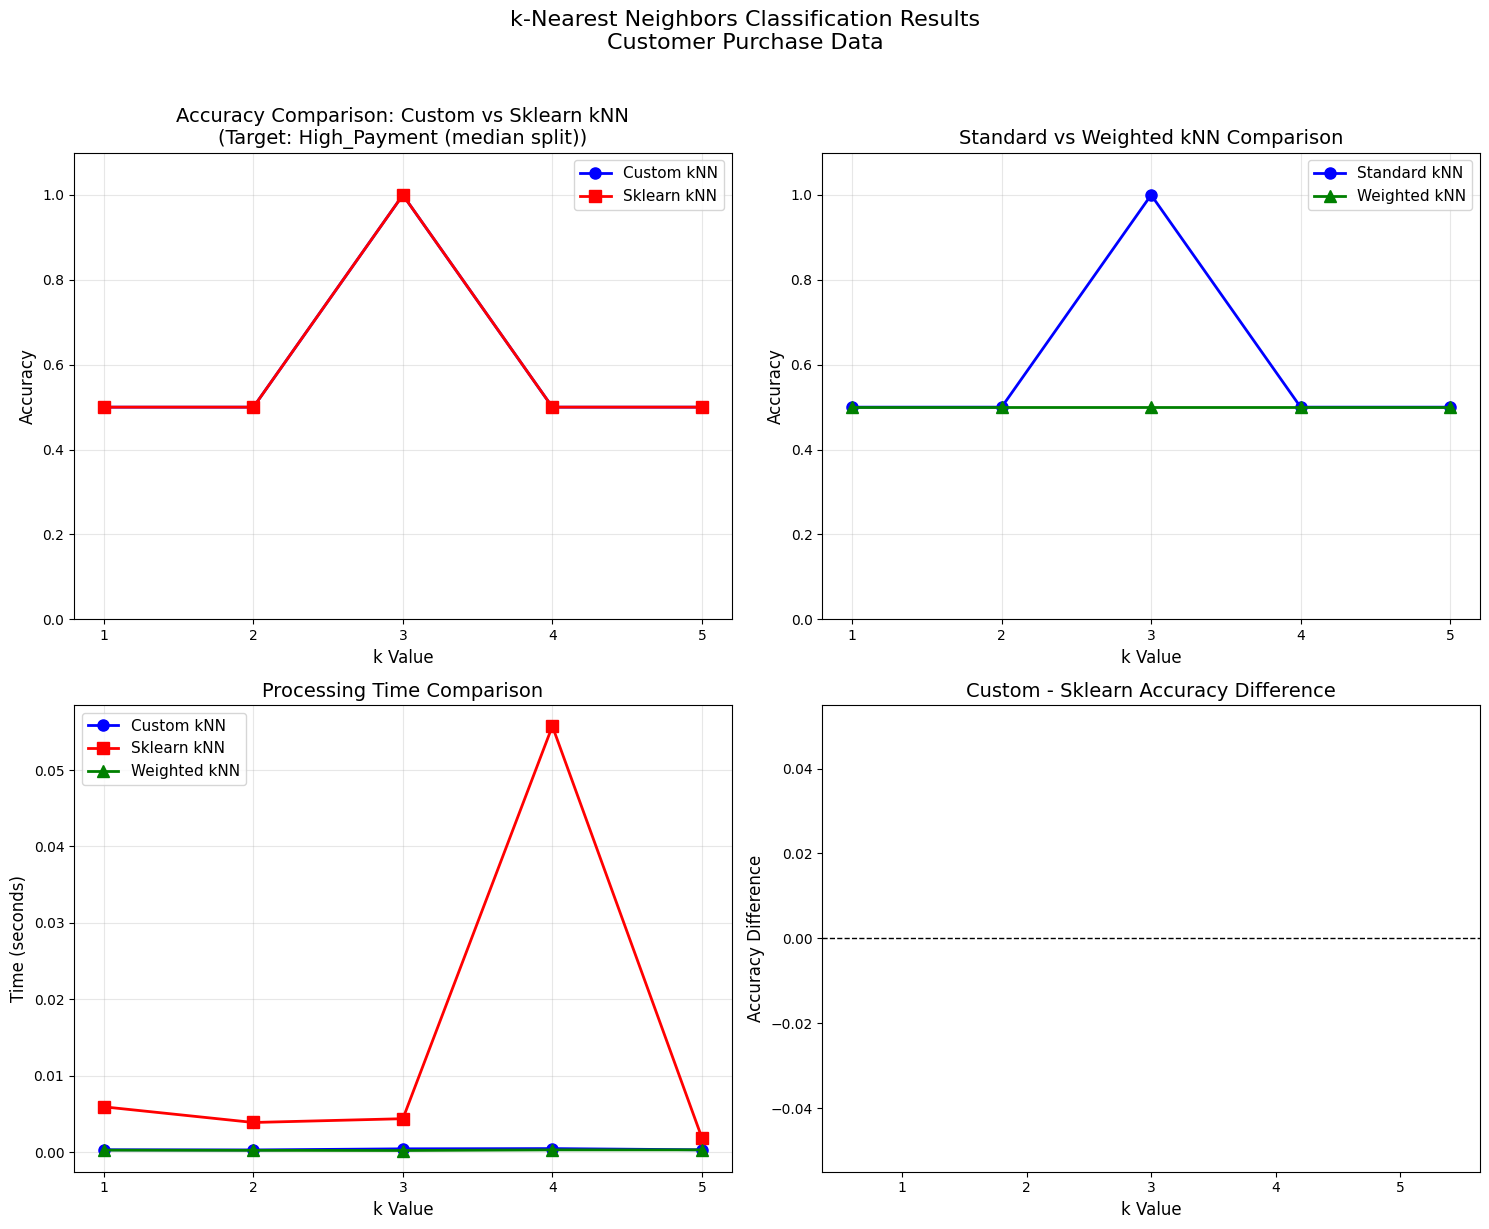


5. DETAILED ANALYSIS FOR REPORT

Dataset Summary:
  - Total samples: 10
  - Features: ['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)', 'Payment (Rs)']
  - Target variable: High_Payment (median split)
  - Target distribution: Counter({np.int64(1): 5, np.int64(0): 5})

a) Overfitting/Underfitting Analysis:

Training vs Test Accuracy:
k=1: Train=1.0000, Test=0.5000, Gap=0.5000
  → Possible overfitting at k=1 (gap=0.5000)
k=2: Train=0.8750, Test=0.5000, Gap=0.3750
k=3: Train=0.8750, Test=1.0000, Gap=-0.1250
k=4: Train=0.8750, Test=0.5000, Gap=0.3750
k=5: Train=0.8750, Test=0.5000, Gap=0.3750

b) Class Separation Analysis:

Computing class separation metrics...
Class 0: 4 samples, Mean intra-distance: 2.2505
Class 1: 4 samples, Mean intra-distance: 2.7308

Inter-class distance: 3.1803
Average intra-class distance: 2.4907

 Classes appear WELL SEPARATED


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================
# PART 1: DATA LOADING AND PREPROCESSING
# ============================================

def load_data_from_excel(excel_path, sheet_name=0):
    """
    Load data from Excel file containing customer purchase data
    """
    # Read Excel file
    df = pd.read_excel(excel_path, sheet_name=sheet_name)

    print(f"Excel file loaded successfully!")
    print(f"Columns found: {df.columns.tolist()}")
    print(f"Shape: {df.shape}")
    print(f"\nFirst 5 rows:")
    print(df.head())


    # Identify feature columns and target columns
    feature_cols = ['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)', 'Payment (Rs)']
    target_cols = ['Candy', 'Mango', 'Milk']

    # Check which columns exist
    available_features = [col for col in feature_cols if col in df.columns]
    available_targets = [col for col in target_cols if col in df.columns]

    print(f"\nAvailable features: {available_features}")
    print(f"Available targets: {available_targets}")

    # Extract features
    X = df[available_features].values

    # For this dataset, we need to handle the targets carefully
    # The target values are in the last 3 columns
    target_results = {}

    for target in available_targets:
        y_raw = df[target].values
        # Convert to binary (0/1) based on whether value > 0 or not
        # This handles the NaN and numeric values properly
        y_binary = np.zeros_like(y_raw, dtype=int)
        for i, val in enumerate(y_raw):
            if pd.notna(val) and val > 0:
                y_binary[i] = 1
            else:
                y_binary[i] = 0

        unique, counts = np.unique(y_binary, return_counts=True)
        target_results[target] = {
            'y': y_binary,
            'distribution': dict(zip(unique, counts)),
            'balance_ratio': min(counts) / max(counts) if len(counts) > 1 else 0
        }

    # Print target distributions
    print("\nTarget distributions (binary: 0=No, 1=Yes):")
    for target, results in target_results.items():
        print(f"  {target}: {results['distribution']} (Balance ratio: {results['balance_ratio']:.2f})")

    # Choose the best balanced target
    # We need at least 2 samples in each class for stratified split
    best_target = None
    best_ratio = 0

    for target, results in target_results.items():
        dist = results['distribution']
        # Check if both classes have at least 2 samples
        if all(count >= 2 for count in dist.values()):
            if results['balance_ratio'] > best_ratio:
                best_ratio = results['balance_ratio']
                best_target = target

    if best_target is None:
        # If no target has both classes with >=2 samples, use binary threshold on Payment
        print("\nAll targets are too imbalanced. Creating target from Payment...")
        payment = df['Payment (Rs)'].values
        median_payment = np.median(payment)
        y_binary = (payment > median_payment).astype(int)
        target_name = 'High_Payment (median split)'
        target_results = {'High_Payment': {'y': y_binary, 'distribution': Counter(y_binary)}}
    else:
        target_name = best_target

    y = target_results[best_target]['y'] if best_target else y_binary

    print(f"\nUsing '{target_name}' as target variable")
    print(f"Target distribution: {Counter(y)}")

    # Handle missing values in features
    X = impute_missing_values(X, strategy='mean')

    print(f"\nFeature matrix shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"Target classes: {np.unique(y)}")

    return X, y, available_features, target_name

def encode_categorical(data):
    """Convert categorical data to numerical using label encoding"""
    if isinstance(data, (list, np.ndarray)):
        unique_values = np.unique(data)
        mapping = {value: idx for idx, value in enumerate(unique_values)}
        encoded_data = np.array([mapping[val] for val in data])
        return encoded_data, mapping
    return data, {}

def impute_missing_values(data, strategy='mean'):
    """Impute missing values in data"""
    data_copy = data.copy()

    if len(data_copy.shape) == 1:
        data_copy = data_copy.reshape(-1, 1)

    for col in range(data_copy.shape[1]):
        col_data = data_copy[:, col]
        if np.any(pd.isna(col_data)):
            if strategy == 'mean':
                mean_val = np.nanmean(col_data)
                data_copy[pd.isna(col_data), col] = mean_val
            elif strategy == 'median':
                median_val = np.nanmedian(col_data)
                data_copy[pd.isna(col_data), col] = median_val
            elif strategy == 'mode':
                from scipy import stats
                mode_val = stats.mode(col_data[~pd.isna(col_data)])[0][0]
                data_copy[pd.isna(col_data), col] = mode_val

    return data_copy

def scale_features(X_train, X_test):
    """Scale features using StandardScaler"""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler

# ============================================
# PART 2: DISTANCE CALCULATIONS
# ============================================

def calculate_distance(point1, point2, metric='euclidean'):
    """Calculate distance between two points"""
    point1 = np.array(point1)
    point2 = np.array(point2)

    if metric == 'euclidean':
        return np.sqrt(np.sum((point1 - point2) ** 2))
    elif metric == 'manhattan':
        return np.sum(np.abs(point1 - point2))
    elif metric == 'minkowski':
        return np.sum(np.abs(point1 - point2) ** 3) ** (1/3)
    else:
        return np.sqrt(np.sum((point1 - point2) ** 2))

def bubble_sort(arr):
    """Bubble sort implementation"""
    arr = list(arr)
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j][0] > arr[j + 1][0]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

def quick_sort(arr):
    """Quick sort implementation"""
    if len(arr) <= 1:
        return arr

    pivot = arr[0]
    left = [x for x in arr[1:] if x[0] <= pivot[0]]
    right = [x for x in arr[1:] if x[0] > pivot[0]]

    return quick_sort(left) + [pivot] + quick_sort(right)

def merge_sort(arr):
    """Merge sort implementation"""
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i][0] <= right[j][0]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result

def sort_with_algorithm(distances, algorithm='quick'):
    """Sort distances using specified algorithm"""
    if algorithm == 'bubble':
        return bubble_sort(distances)
    elif algorithm == 'quick':
        return quick_sort(distances)
    elif algorithm == 'merge':
        return merge_sort(distances)
    else:
        return sorted(distances, key=lambda x: x[0])

# ============================================
# PART 4: CUSTOM KNN CLASSIFIER
# ============================================

class CustomKNNClassifier:
    """Custom k-Nearest Neighbors Classifier"""

    def __init__(self, k=3, distance_metric='euclidean',
                 sorting_algorithm='quick', weighted=False):
        self.k = min(k, 10)
        self.distance_metric = distance_metric
        self.sorting_algorithm = sorting_algorithm
        self.weighted = weighted
        self.X_train = None
        self.y_train = None
        self.classes_ = None

    def fit(self, X, y):
        """Fit the kNN classifier"""
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        self.classes_ = np.unique(y)
        self.k = min(self.k, len(self.X_train))
        return self

    def _calculate_all_distances(self, test_point):
        """Calculate distances from test point to all training points"""
        distances = []
        for i, train_point in enumerate(self.X_train):
            dist = calculate_distance(test_point, train_point, self.distance_metric)
            distances.append((dist, i))
        return distances

    def _find_neighbors(self, test_point):
        """Find k nearest neighbors with tie-breaking"""
        distances = self._calculate_all_distances(test_point)
        sorted_distances = sort_with_algorithm(distances, self.sorting_algorithm)

        k_neighbors = sorted_distances[:self.k]

        if len(sorted_distances) > self.k:
            kth_distance = sorted_distances[self.k - 1][0]
            ties = [idx for dist, idx in sorted_distances[self.k:]
                   if abs(dist - kth_distance) < 1e-10]

            if ties:
                all_candidates = [idx for _, idx in sorted_distances[:self.k]] + ties
                import random
                k_neighbors = [(sorted_distances[self.k-1][0], idx)
                              for idx in random.sample(all_candidates, self.k)]

        return k_neighbors

    def _majority_vote(self, neighbors):
        """Perform majority voting with tie-breaking"""
        neighbor_labels = [self.y_train[idx] for _, idx in neighbors]

        if self.weighted:
            weights = []
            for dist, idx in neighbors:
                if dist < 1e-10:
                    return self.y_train[idx]
                weights.append(1.0 / (dist + 1e-10))

            class_weights = {}
            for label, weight in zip(neighbor_labels, weights):
                class_weights[label] = class_weights.get(label, 0) + weight

            max_weight = max(class_weights.values())
            candidates = [label for label, w in class_weights.items()
                         if abs(w - max_weight) < 1e-10]

            if len(candidates) > 1:
                vote_counts = Counter(neighbor_labels)
                max_count = max(vote_counts.values())
                final_candidates = [label for label in candidates
                                  if vote_counts[label] == max_count]
                return min(final_candidates)
            return candidates[0]

        else:
            vote_counts = Counter(neighbor_labels)
            max_votes = max(vote_counts.values())
            candidates = [label for label, count in vote_counts.items()
                         if count == max_votes]
            return min(candidates)

    def predict(self, X):
        """Predict labels for test data"""
        X = np.array(X)
        predictions = []

        for test_point in X:
            neighbors = self._find_neighbors(test_point)
            pred = self._majority_vote(neighbors)
            predictions.append(pred)

        return np.array(predictions)

    def score(self, X, y):
        """Calculate accuracy of the classifier"""
        predictions = self.predict(X)
        return np.mean(predictions == y)

# ============================================
# PART 5: MAIN EXECUTION
# ============================================

def main():
    """Main execution function"""
    print("=" * 60)
    print("k-NEAREST NEIGHBORS CLASSIFIER IMPLEMENTATION")
    print("Customer Purchase Data Classification")
    print("=" * 60)

    # ================================
    # Step 1: Load Data from Excel
    # ================================
    print("\n1. LOADING DATA FROM EXCEL...")
    print("-" * 40)


    excel_path = "/content/Lab_Session_Data__1_.xlsx"

    try:
        # Load data
        X, y, feature_names, target_name = load_data_from_excel(excel_path)

        if len(X) == 0:
            print("\nError: No data loaded.")
            return

        # Check if we have enough samples in each class
        class_counts = Counter(y)
        print(f"\nClass distribution: {class_counts}")

        # If any class has < 2 samples, we can't use stratified split
        use_stratify = all(count >= 2 for count in class_counts.values())

        if not use_stratify:
            print("\nWarning: Some classes have very few samples. Using simple split without stratification.")
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )
        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )

        print(f"\nTraining set: {len(X_train)} samples")
        print(f"Test set: {len(X_test)} samples")
        print(f"Training class distribution: {Counter(y_train)}")
        print(f"Test class distribution: {Counter(y_test)}")

        # Scale features
        X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

    except Exception as e:
        print(f"Error loading data: {e}")
        print("\nError details:", str(e))
        return

    # ================================
    # Step 2: Compare Custom vs Sklearn kNN
    # ================================
    print("\n2. COMPARING CUSTOM vs SKLEARN kNN...")


    # Adjust k values based on training set size
    max_k = min(len(X_train), 5)
    k_values = list(range(1, max_k + 1))

    custom_accuracies = []
    sklearn_accuracies = []
    custom_times = []
    sklearn_times = []

    print(f"\nTarget variable: {target_name}")
    print(f"Features: {feature_names}")
    print(f"Training samples: {len(X_train)}")
    print(f"Testing samples: {len(X_test)}")
    print(f"Maximum k value: {max_k}")

    for k in k_values:
        print(f"\nTesting with k={k}")

        # Custom kNN
        start_time = time.time()
        custom_knn = CustomKNNClassifier(k=k, distance_metric='euclidean',
                                        sorting_algorithm='quick', weighted=False)
        custom_knn.fit(X_train_scaled, y_train)
        custom_acc = custom_knn.score(X_test_scaled, y_test)
        custom_time = time.time() - start_time
        custom_accuracies.append(custom_acc)
        custom_times.append(custom_time)

        # Sklearn kNN
        start_time = time.time()
        sklearn_knn = KNeighborsClassifier(n_neighbors=k)
        sklearn_knn.fit(X_train_scaled, y_train)
        sklearn_acc = sklearn_knn.score(X_test_scaled, y_test)
        sklearn_time = time.time() - start_time
        sklearn_accuracies.append(sklearn_acc)
        sklearn_times.append(sklearn_time)

        print(f"Custom kNN Accuracy: {custom_acc:.4f} (Time: {custom_time:.4f}s)")
        print(f"Sklearn kNN Accuracy: {sklearn_acc:.4f} (Time: {sklearn_time:.4f}s)")

    # ================================
    # Step 3: Weighted kNN
    # ================================
    print("\n3. WEIGHTED kNN IMPLEMENTATION...")


    weighted_accuracies = []
    weighted_times = []

    for k in k_values:
        start_time = time.time()
        weighted_knn = CustomKNNClassifier(k=k, distance_metric='euclidean',
                                          sorting_algorithm='quick', weighted=True)
        weighted_knn.fit(X_train_scaled, y_train)
        weighted_acc = weighted_knn.score(X_test_scaled, y_test)
        weighted_time = time.time() - start_time
        weighted_accuracies.append(weighted_acc)
        weighted_times.append(weighted_time)
        print(f"k={k}: Weighted kNN Accuracy = {weighted_acc:.4f} (Time: {weighted_time:.4f}s)")

    # ================================
    # Step 4: Plot Results
    # ================================
    print("\n4. GENERATING PLOTS...")


    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Accuracy Comparison
    ax1 = axes[0, 0]
    ax1.plot(k_values, custom_accuracies, 'b-o', label='Custom kNN', linewidth=2, markersize=8)
    ax1.plot(k_values, sklearn_accuracies, 'r-s', label='Sklearn kNN', linewidth=2, markersize=8)
    ax1.set_xlabel('k Value', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title(f'Accuracy Comparison: Custom vs Sklearn kNN\n(Target: {target_name})', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    ax1.set_xticks(k_values)
    ax1.set_ylim([0, 1.1])

    # Plot 2: Weighted vs Standard
    ax2 = axes[0, 1]
    ax2.plot(k_values, custom_accuracies, 'b-o', label='Standard kNN', linewidth=2, markersize=8)
    ax2.plot(k_values, weighted_accuracies, 'g-^', label='Weighted kNN', linewidth=2, markersize=8)
    ax2.set_xlabel('k Value', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Standard vs Weighted kNN Comparison', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    ax2.set_xticks(k_values)
    ax2.set_ylim([0, 1.1])

    # Plot 3: Time Comparison
    ax3 = axes[1, 0]
    ax3.plot(k_values, custom_times, 'b-o', label='Custom kNN', linewidth=2, markersize=8)
    ax3.plot(k_values, sklearn_times, 'r-s', label='Sklearn kNN', linewidth=2, markersize=8)
    ax3.plot(k_values, weighted_times, 'g-^', label='Weighted kNN', linewidth=2, markersize=8)
    ax3.set_xlabel('k Value', fontsize=12)
    ax3.set_ylabel('Time (seconds)', fontsize=12)
    ax3.set_title('Processing Time Comparison', fontsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=11)
    ax3.set_xticks(k_values)

    # Plot 4: Accuracy Difference
    ax4 = axes[1, 1]
    acc_diff = np.array(custom_accuracies) - np.array(sklearn_accuracies)
    colors = ['green' if d >= 0 else 'red' for d in acc_diff]
    ax4.bar(k_values, acc_diff, color=colors, alpha=0.7)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax4.set_xlabel('k Value', fontsize=12)
    ax4.set_ylabel('Accuracy Difference', fontsize=12)
    ax4.set_title('Custom - Sklearn Accuracy Difference', fontsize=14)
    ax4.set_xticks(k_values)

    plt.suptitle('k-Nearest Neighbors Classification Results\nCustomer Purchase Data', fontsize=16, y=1.02)
    plt.tight_layout()

    # Save plots
    plt.savefig('knn_results.png', dpi=300, bbox_inches='tight')
    print("Plots saved as 'knn_results.png'")
    plt.show()

    # ================================
    # Step 5: Detailed Analysis
    # ================================
    print("\n5. DETAILED ANALYSIS FOR REPORT")


    print(f"\nDataset Summary:")
    print(f"  - Total samples: {len(X)}")
    print(f"  - Features: {feature_names}")
    print(f"  - Target variable: {target_name}")
    print(f"  - Target distribution: {Counter(y)}")

    print("\na) Overfitting/Underfitting Analysis:")

    # Analyze training accuracy
    print("\nTraining vs Test Accuracy:")
    for k in k_values:
        custom_knn = CustomKNNClassifier(k=k)
        custom_knn.fit(X_train_scaled, y_train)
        train_acc = custom_knn.score(X_train_scaled, y_train)
        test_acc = custom_knn.score(X_test_scaled, y_test)
        gap = train_acc - test_acc
        print(f"k={k}: Train={train_acc:.4f}, Test={test_acc:.4f}, Gap={gap:.4f}")

        if k == 1 and gap > 0.1:
            print(f"  → Possible overfitting at k=1 (gap={gap:.4f})")
        if k == max_k and gap < 0.02:
            print(f"  → Possible underfitting at k={max_k} (gap={gap:.4f})")

    print("\nb) Class Separation Analysis:")

    # Check class separation
    print("\nComputing class separation metrics...")
    class_distances = {}
    for class_label in np.unique(y_train):
        class_indices = np.where(y_train == class_label)[0]
        class_samples = X_train_scaled[class_indices]

        intra_distances = []
        sample_limit = min(5, len(class_samples))
        for i in range(sample_limit):
            for j in range(i+1, sample_limit):
                dist = calculate_distance(class_samples[i], class_samples[j], 'euclidean')
                intra_distances.append(dist)

        class_distances[class_label] = {
            'intra_mean': np.mean(intra_distances) if intra_distances else 0,
            'samples': len(class_indices)
        }

    for class_label, stats in class_distances.items():
        print(f"Class {class_label}: {stats['samples']} samples, "
              f"Mean intra-distance: {stats['intra_mean']:.4f}")

    if len(np.unique(y_train)) >= 2:
        class1 = np.unique(y_train)[0]
        class2 = np.unique(y_train)[1]
        class1_samples = X_train_scaled[y_train == class1][:5]
        class2_samples = X_train_scaled[y_train == class2][:5]

        inter_distances = []
        for s1 in class1_samples:
            for s2 in class2_samples:
                if len(s1) > 0 and len(s2) > 0:
                    dist = calculate_distance(s1, s2, 'euclidean')
                    inter_distances.append(dist)

        if inter_distances:
            inter_mean = np.mean(inter_distances)
            intra_mean_class1 = class_distances[class1]['intra_mean']
            intra_mean_class2 = class_distances[class2]['intra_mean']

            print(f"\nInter-class distance: {inter_mean:.4f}")
            print(f"Average intra-class distance: {(intra_mean_class1 + intra_mean_class2) / 2:.4f}")

            if inter_mean > (intra_mean_class1 + intra_mean_class2) / 2:
                print("\n Classes appear WELL SEPARATED")
            else:
                print("\n✗ Classes may NOT BE WELL SEPARATED")
        else:
            print("\n⚠ Insufficient samples for inter-class distance calculation")

if __name__ == "__main__":
    main()